# Weekend NC Climate Phase Comparison

Group PICASO-climate grid runs that share the same input parameters but differ only in **observational phase angle** (0°, 60°, 120°). For each triplet (A, B, C):

1. Compute pairwise P–T profile differences: A−B, A−C, B−C vs pressure
2. Derive **max absolute deviation** and **RMS difference** per pair

If climate is independent of phase angle, all three profiles should be identical and every difference should be zero.

In [1]:
from __future__ import annotations

import json
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

REPO_ROOT = Path.cwd()
NC_DIR = REPO_ROOT / "outputs" / "weekend_nc"

CLIMATE_KEY_SKIP = {
    "phase_deg",
    "run_index",
    "run_id",
    "output_nc",
    "status",
    "source_notebook_reference",
    "project",
    "model_name",
    "author",
    "contact",
    "notes",
    "code",
}

PHASE_LABELS = {0.0: "A", 60.0: "B", 120.0: "C"}
PAIR_NAMES = [("A", "B"), ("A", "C"), ("B", "C")]

NOISE_TOL_K = 1e-3
FLAG_TOL_K = 0.1

print(f"Repo root: {REPO_ROOT}")
print(f"NetCDF directory: {NC_DIR}")

Repo root: /Users/dhuang/Documents/daniel/research/aurora
NetCDF directory: /Users/dhuang/Documents/daniel/research/aurora/outputs/weekend_nc


In [2]:
def climate_key(manifest_row: dict) -> tuple:
    return tuple(sorted((k, v) for k, v in manifest_row.items() if k not in CLIMATE_KEY_SKIP))


def load_manifest(path: Path) -> dict:
    with xr.open_dataset(path) as ds:
        row = json.loads(ds.attrs["source_manifest_row"])
    row["phase_deg"] = float(row["phase_deg"])
    row["run_index"] = int(row["run_index"])
    return row


def load_pt_profile(path: Path) -> tuple[np.ndarray, np.ndarray]:
    with xr.open_dataset(path) as ds:
        pressure = np.asarray(ds["pressure_bar"].values, dtype=float)
        temperature = np.asarray(ds["temperature_k"].values, dtype=float)
    return pressure, temperature


nc_files = sorted(path for path in NC_DIR.glob("run_*.nc") if not path.name.endswith(".tmp.nc"))
if not nc_files:
    raise FileNotFoundError(f"No .nc files found in {NC_DIR}")

print(f"Found {len(nc_files)} NetCDF files")

groups: dict[tuple, list[dict]] = defaultdict(list)
for path in nc_files:
    row = load_manifest(path)
    groups[climate_key(row)].append({"path": path, "manifest": row})

triplets = []
orphans = []
odd_groups = []
for key, members in groups.items():
    if len(members) == 3:
        members = sorted(members, key=lambda m: m["manifest"]["phase_deg"])
        triplets.append(members)
    elif len(members) == 1:
        orphans.append(members[0])
    else:
        odd_groups.append(members)

phase_sets = Counter(tuple(m["manifest"]["phase_deg"] for m in t) for t in triplets)
print(f"Climate triplets (3 phases): {len(triplets)}")
print(f"Orphan files (no phase partners): {len(orphans)}")
print(f"Odd-sized groups: {len(odd_groups)}")
print(f"Phase combinations in triplets: {dict(phase_sets)}")

if orphans:
    display(pd.DataFrame([{"file": m["path"].name, "phase_deg": m["manifest"]["phase_deg"]} for m in orphans]))

Found 1384 NetCDF files
Climate triplets (3 phases): 461
Orphan files (no phase partners): 1
Odd-sized groups: 0
Phase combinations in triplets: {(0.0, 60.0, 120.0): 461}


,file,phase_deg
0,run_0000347.nc,120.0


In [3]:
def pair_metrics(pressure: np.ndarray, t_left: np.ndarray, t_right: np.ndarray) -> dict:
    dT = t_left - t_right
    abs_dT = np.abs(dT)
    idx_max = int(np.argmax(abs_dT))
    return {
        "pressure_bar": pressure,
        "dT_K": dT,
        "max_abs_dT_K": float(abs_dT[idx_max]),
        "pressure_at_max_bar": float(pressure[idx_max]),
        "rms_dT_K": float(np.sqrt(np.mean(dT**2))),
    }


summary_rows = []
triplet_profiles = []

for group_id, members in enumerate(triplets):
    profiles = []
    for member in members:
        pressure, temperature = load_pt_profile(member["path"])
        phase = member["manifest"]["phase_deg"]
        profiles.append(
            {
                "label": PHASE_LABELS.get(phase, f"phase{phase:g}"),
                "phase_deg": phase,
                "file": member["path"].name,
                "pressure_bar": pressure,
                "temperature_k": temperature,
            }
        )

    p_ref = profiles[0]["pressure_bar"]
    for prof in profiles[1:]:
        if not np.allclose(prof["pressure_bar"], p_ref):
            raise ValueError(f"Pressure grids differ in group {group_id}: {profiles[0]['file']} vs {prof['file']}")

    by_label = {p["label"]: p for p in profiles}
    manifest = members[0]["manifest"]
    pair_results = {}
    for left, right in PAIR_NAMES:
        metrics = pair_metrics(
            p_ref,
            by_label[left]["temperature_k"],
            by_label[right]["temperature_k"],
        )
        pair_key = f"{left}-{right}"
        pair_results[pair_key] = metrics
        summary_rows.append(
            {
                "group_id": group_id,
                "pair": pair_key,
                "file_A": by_label["A"]["file"],
                "file_B": by_label["B"]["file"],
                "file_C": by_label["C"]["file"],
                "equilibrium_temperature_k": float(manifest["equilibrium_temperature_k"]),
                "planet_radius_rearth": float(manifest["planet_radius_rearth"]),
                "insolation_searth": float(manifest["insolation_searth"]),
                "cloud_fraction": float(manifest["cloud_fraction"]),
                "fsed": float(manifest["fsed"]),
                "metallicity_xsolar": float(manifest["metallicity_xsolar"]),
                "max_abs_dT_K": metrics["max_abs_dT_K"],
                "pressure_at_max_bar": metrics["pressure_at_max_bar"],
                "rms_dT_K": metrics["rms_dT_K"],
            }
        )

    triplet_profiles.append({"group_id": group_id, "profiles": profiles, "pair_results": pair_results})

summary_df = pd.DataFrame(summary_rows)
print(f"Computed {len(summary_df)} pairwise comparisons across {len(triplets)} triplets")
display(summary_df.head(10))

Computed 1383 pairwise comparisons across 461 triplets


,group_id,pair,file_A,file_B,file_C,equilibrium_temperature_k,planet_radius_rearth,insolation_searth,cloud_fraction,fsed,metallicity_xsolar,max_abs_dT_K,pressure_at_max_bar,rms_dT_K
0,0,A-B,run_0000000.nc,run_0000001.nc,run_0000002.nc,254.585773,2.0,0.7,0.0,1.0,1.0,0.0,0.000001,0.0
1,0,A-C,run_0000000.nc,run_0000001.nc,run_0000002.nc,254.585773,2.0,0.7,0.0,1.0,1.0,0.0,0.000001,0.0
2,0,B-C,run_0000000.nc,run_0000001.nc,run_0000002.nc,254.585773,2.0,0.7,0.0,1.0,1.0,0.0,0.000001,0.0
3,1,A-B,run_0000003.nc,run_0000004.nc,run_0000005.nc,308.022495,2.0,1.5,0.0,1.0,1.0,0.0,0.000001,0.0
4,1,A-C,run_0000003.nc,run_0000004.nc,run_0000005.nc,308.022495,2.0,1.5,0.0,1.0,1.0,0.0,0.000001,0.0
5,1,B-C,run_0000003.nc,run_0000004.nc,run_0000005.nc,308.022495,2.0,1.5,0.0,1.0,1.0,0.0,0.000001,0.0
6,2,A-B,run_0000006.nc,run_0000007.nc,run_0000008.nc,254.585773,2.0,0.7,0.0,6.0,1.0,0.0,0.000001,0.0
7,2,A-C,run_0000006.nc,run_0000007.nc,run_0000008.nc,254.585773,2.0,0.7,0.0,6.0,1.0,0.0,0.000001,0.0
8,2,B-C,run_0000006.nc,run_0000007.nc,run_0000008.nc,254.585773,2.0,0.7,0.0,6.0,1.0,0.0,0.000001,0.0
9,3,A-B,run_0000009.nc,run_0000010.nc,run_0000011.nc,308.022495,2.0,1.5,0.0,6.0,1.0,0.0,0.000001,0.0


In [4]:
def classify_row(max_abs_dT_K: float) -> str:
    if max_abs_dT_K == 0.0:
        return "exact"
    if max_abs_dT_K < NOISE_TOL_K:
        return "noise"
    if max_abs_dT_K > FLAG_TOL_K:
        return "flag"
    return "small"


summary_df["status"] = summary_df["max_abs_dT_K"].map(classify_row)

group_max = summary_df.groupby("group_id")["max_abs_dT_K"].max()
identical_groups = int((group_max == 0.0).sum())
noise_groups = int(((group_max > 0.0) & (group_max < NOISE_TOL_K)).sum())
flag_groups = int((group_max > FLAG_TOL_K).sum())

print(f"Triplets with exact match (max|dT| = 0): {identical_groups} / {len(triplets)}")
print(f"Triplets with only numerical noise (max|dT| < {NOISE_TOL_K} K): {noise_groups}")
print(f"Triplets flagged for investigation (max|dT| > {FLAG_TOL_K} K): {flag_groups}")
print()
print("Status counts per pairwise comparison:")
display(summary_df["status"].value_counts().to_frame("count"))

outliers_df = summary_df[summary_df["status"] == "flag"].sort_values("max_abs_dT_K", ascending=False)
if not outliers_df.empty:
    print("\nFlagged outlier pairs:")
    display(outliers_df)

Triplets with exact match (max|dT| = 0): 458 / 461
Triplets with only numerical noise (max|dT| < 0.001 K): 0
Triplets flagged for investigation (max|dT| > 0.1 K): 2

Status counts per pairwise comparison:


,count
status,
exact,1377
flag,4
small,2



Flagged outlier pairs:


,group_id,pair,file_A,file_B,file_C,equilibrium_temperature_k,planet_radius_rearth,insolation_searth,cloud_fraction,fsed,metallicity_xsolar,max_abs_dT_K,pressure_at_max_bar,rms_dT_K,status
1309,436,A-C,run_0001620.nc,run_0001621.nc,run_0001622.nc,254.585773,3.0,0.7,1.0,1.0,1.0,6.013327,31.622777,2.235406,flag
1310,436,B-C,run_0001620.nc,run_0001621.nc,run_0001622.nc,254.585773,3.0,0.7,1.0,1.0,1.0,6.013327,31.622777,2.235406,flag
1287,429,A-B,run_0001599.nc,run_0001600.nc,run_0001601.nc,308.022495,3.0,1.5,1.0,1.0,1.0,2.324460,31.622777,1.053919,flag
1288,429,A-C,run_0001599.nc,run_0001600.nc,run_0001601.nc,308.022495,3.0,1.5,1.0,1.0,1.0,2.324460,31.622777,1.053919,flag


## How to read these plots

**A, B, C** = same climate inputs, phases **0° / 60° / 120°** only.

| Panel | What it shows |
|-------|----------------|
| **Full T(P)** | All three temperature profiles. If two phases produced the **same** climate solve, their curves draw on top of each other — the legend will show e.g. `B ≡ C (60°, 120°)` instead of three separate lines. |
| **Zoom T(P)** | Same profiles, magnified near the pressure where **max \|ΔT\|** occurs. Use this when the full-scale plot looks like "one line" but the difference panel shows nonzero values. |
| **ΔT(P)** | Pairwise differences (A−B, A−C, B−C). **This is the diagnostic panel.** A flat line at zero means those two profiles are identical. |

**Typical case (458/461 triplets):** one line on the full T(P) plot, all ΔT curves flat at zero — climate does not depend on phase angle.

**Outlier case:** two phases identical, one phase re-converged to a slightly different PICASO climate (only at `cloud_fraction = 1.0`). You will see two distinct curves in the zoom panel and nonzero ΔT for only some pairs.

In [5]:
def group_identical_profiles(profiles: list[dict]) -> list[list[dict]]:
    """Cluster profiles with bit-identical temperature arrays."""
    clusters: list[list[dict]] = []
    for prof in profiles:
        for cluster in clusters:
            if np.array_equal(prof["temperature_k"], cluster[0]["temperature_k"]):
                cluster.append(prof)
                break
        else:
            clusters.append([prof])
    return clusters


def format_profile_cluster_label(cluster: list[dict]) -> str:
    if len(cluster) == 1:
        prof = cluster[0]
        return f"{prof['label']} ({prof['phase_deg']:.0f}°)"
    labels = " ≡ ".join(prof["label"] for prof in cluster)
    phases = ", ".join(f"{prof['phase_deg']:.0f}°" for prof in cluster)
    return f"{labels} ({phases})"


def identical_pair_notes(pair_results: dict) -> str:
    """Summarize which pairs are exactly zero difference."""
    identical = [pair for pair, metrics in pair_results.items() if metrics["max_abs_dT_K"] == 0.0]
    if len(identical) == 3:
        return "A ≡ B ≡ C (all identical)"
    if identical:
        return "Identical pairs: " + ", ".join(identical)
    return "No identical pairs"


def zoom_slice(pressure: np.ndarray, idx_center: int, half_width: int = 4) -> slice:
    lo = max(0, idx_center - half_width)
    hi = min(len(pressure), idx_center + half_width + 1)
    return slice(lo, hi)


def plot_triplet_comparison(
    profiles: list[dict],
    pair_results: dict,
    *,
    title: str,
    colors: list[str] | None = None,
) -> None:
    """Three-panel figure: full T(P), zoomed T(P), and pairwise ΔT(P)."""
    colors = colors or ["C0", "C1", "C2", "C3"]
    pressure = profiles[0]["pressure_bar"]
    clusters = group_identical_profiles(profiles)

    nonzero_pairs = [m for m in pair_results.values() if m["max_abs_dT_K"] > 0.0]
    if nonzero_pairs:
        ref_metrics = max(nonzero_pairs, key=lambda m: m["max_abs_dT_K"])
        idx_zoom = int(np.argmin(np.abs(pressure - ref_metrics["pressure_at_max_bar"])))
    else:
        idx_zoom = len(pressure) // 2

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    # --- Panel 1: full T(P), deduplicated legend ---
    ax = axes[0]
    for i, cluster in enumerate(clusters):
        prof = cluster[0]
        ax.semilogx(
            prof["pressure_bar"],
            prof["temperature_k"],
            color=colors[i % len(colors)],
            lw=2,
            label=format_profile_cluster_label(cluster),
        )
    ax.set_xlabel("Pressure [bar]")
    ax.set_ylabel("Temperature [K]")
    ax.set_title("Full T(P)")
    ax.legend(fontsize=9)
    ax.grid(True, which="both", alpha=0.3)
    ax.text(
        0.03,
        0.03,
        identical_pair_notes(pair_results),
        transform=ax.transAxes,
        fontsize=8,
        va="bottom",
        bbox={"boxstyle": "round", "facecolor": "wheat", "alpha": 0.8},
    )

    # --- Panel 2: zoom near max |ΔT| ---
    ax = axes[1]
    sl = zoom_slice(pressure, idx_zoom)
    p_zoom = pressure[sl]
    t_zoom = [prof["temperature_k"][sl] for prof in profiles]
    if nonzero_pairs:
        spread = max(np.ptp(np.column_stack(t_zoom), axis=1))
        margin = max(0.5, spread * 0.15)
        y_lo = float(np.min(t_zoom) - margin)
        y_hi = float(np.max(t_zoom) + margin)
        zoom_title = f"Zoom near P = {pressure[idx_zoom]:.3g} bar"
    else:
        y_lo = y_hi = None
        zoom_title = "Zoom (all profiles identical)"

    for i, cluster in enumerate(clusters):
        prof = cluster[0]
        ax.semilogx(
            p_zoom,
            prof["temperature_k"][sl],
            color=colors[i % len(colors)],
            lw=2,
            marker="o",
            ms=4,
            label=format_profile_cluster_label(cluster),
        )
    if y_lo is not None:
        ax.set_ylim(y_lo, y_hi)
    ax.set_xlabel("Pressure [bar]")
    ax.set_ylabel("Temperature [K]")
    ax.set_title(zoom_title)
    ax.legend(fontsize=9)
    ax.grid(True, which="both", alpha=0.3)

    # --- Panel 3: pairwise ΔT ---
    ax = axes[2]
    pair_colors = {"A-B": "C0", "A-C": "C1", "B-C": "C2"}
    for pair_key, metrics in pair_results.items():
        ls = "-" if metrics["max_abs_dT_K"] > 0 else "--"
        lw = 2 if metrics["max_abs_dT_K"] > 0 else 1.2
        ax.semilogx(
            metrics["pressure_bar"],
            metrics["dT_K"],
            label=f"{pair_key} (max {metrics['max_abs_dT_K']:.3g} K)",
            color=pair_colors.get(pair_key, None),
            ls=ls,
            lw=lw,
        )
    ax.axhline(0.0, color="k", lw=0.8)
    ax.set_xlabel("Pressure [bar]")
    ax.set_ylabel("ΔT [K]")
    max_dT = max(m["max_abs_dT_K"] for m in pair_results.values())
    ax.set_title(f"Pairwise ΔT(P)  |  max = {max_dT:.3g} K")
    ax.legend(fontsize=8)
    ax.grid(True, which="both", alpha=0.3)

    fig.suptitle(title, y=1.02, fontsize=11)
    plt.tight_layout()
    plt.show()

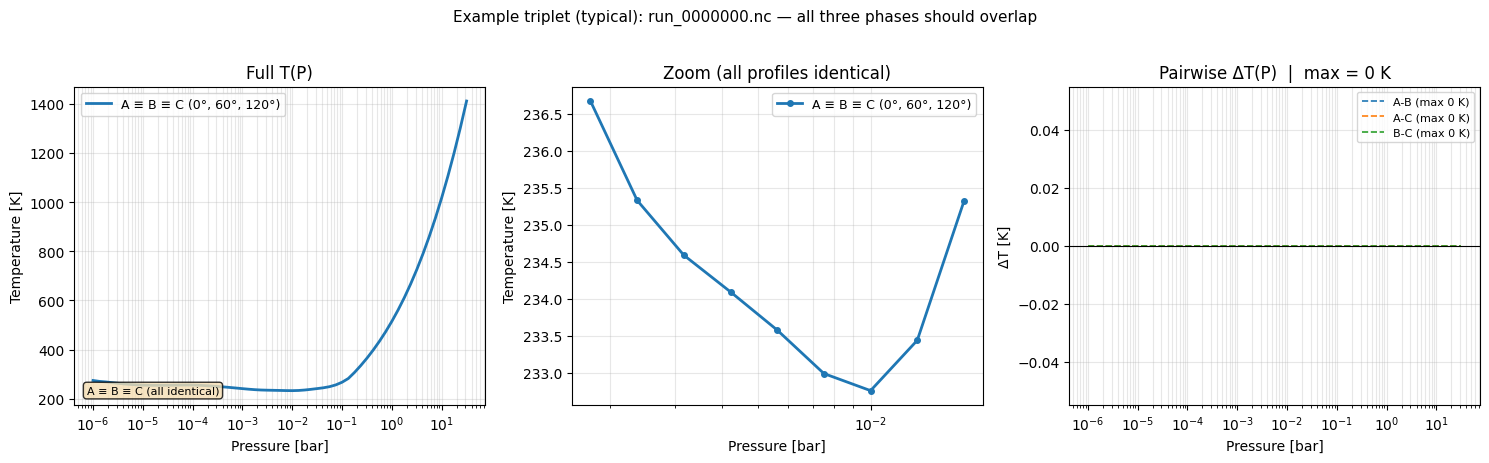

In [6]:
example = triplet_profiles[0]
profiles = example["profiles"]
pair_results = example["pair_results"]

plot_triplet_comparison(
    profiles,
    pair_results,
    title=f"Example triplet (typical): {profiles[0]['file']} — all three phases should overlap",
)

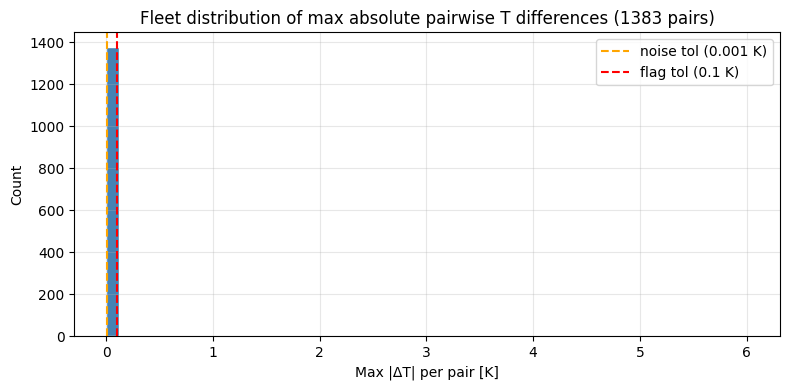

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(summary_df["max_abs_dT_K"], bins=50, color="steelblue", edgecolor="white")
ax.axvline(NOISE_TOL_K, color="orange", ls="--", label=f"noise tol ({NOISE_TOL_K} K)")
ax.axvline(FLAG_TOL_K, color="red", ls="--", label=f"flag tol ({FLAG_TOL_K} K)")
ax.set_xlabel("Max |ΔT| per pair [K]")
ax.set_ylabel("Count")
ax.set_title(f"Fleet distribution of max absolute pairwise T differences ({len(summary_df)} pairs)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

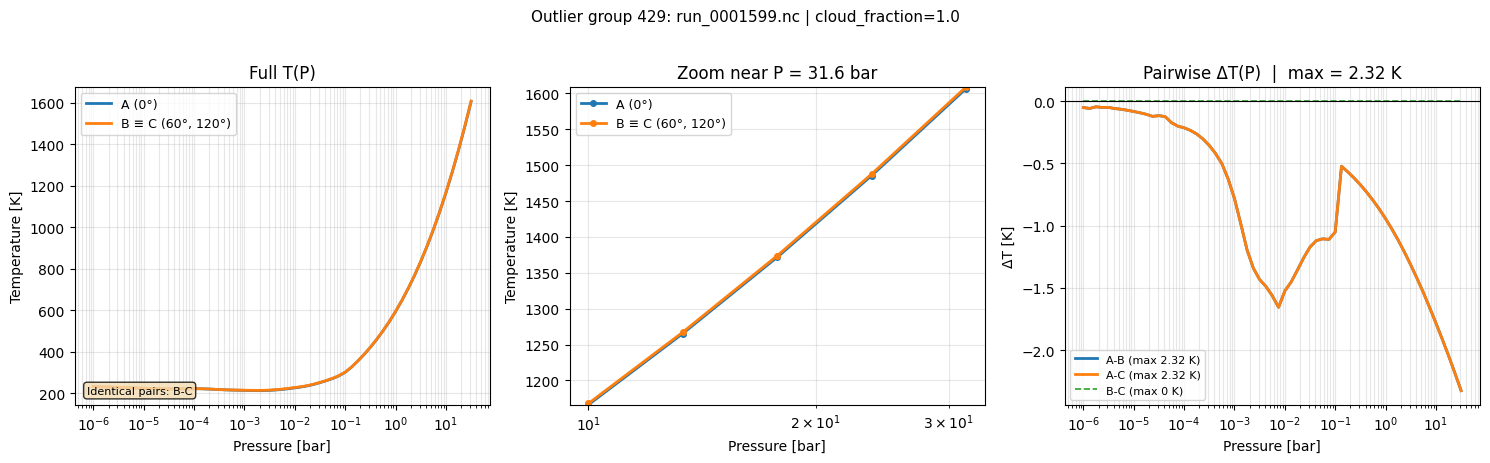

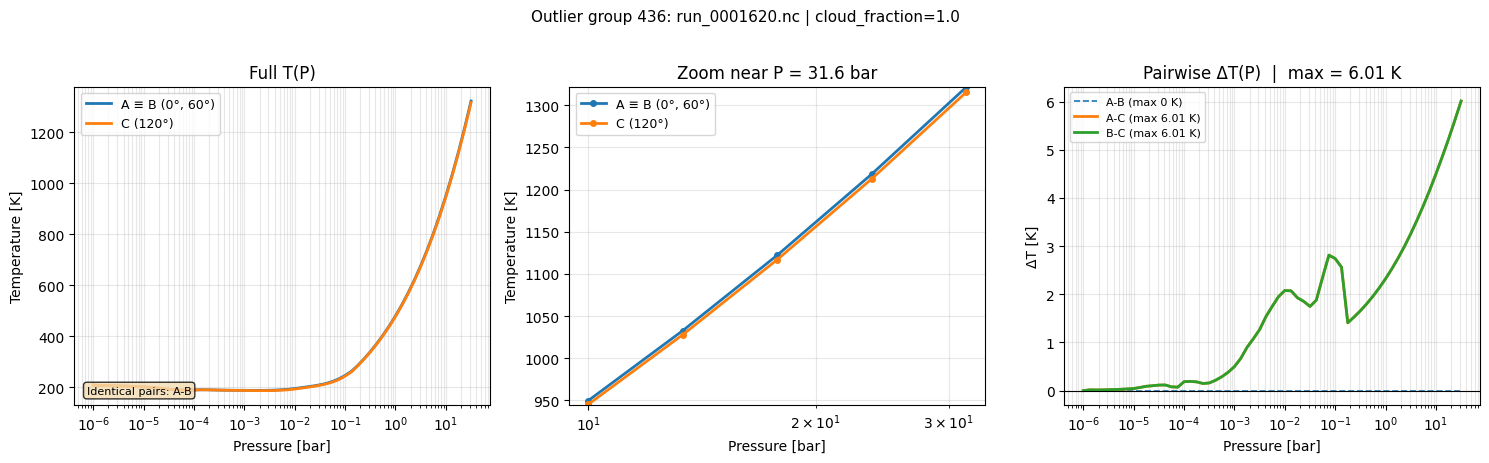

In [8]:
flagged_group_ids = sorted(outliers_df["group_id"].unique()) if not outliers_df.empty else []

if flagged_group_ids:
    for group_id in flagged_group_ids:
        item = triplet_profiles[group_id]
        profiles = item["profiles"]
        pair_results = item["pair_results"]
        plot_triplet_comparison(
            profiles,
            pair_results,
            title=(
                f"Outlier group {group_id}: {profiles[0]['file']} | "
                f"cloud_fraction={summary_df.loc[summary_df.group_id == group_id].iloc[0]['cloud_fraction']}"
            ),
        )
else:
    print("No flagged outlier groups to plot.")

## Conclusion

Run the summary cell above for exact counts. In expectation:

- **~458 / 461** climate triplets have **identical** P–T profiles across phase angles (A, B, C differ only in observational geometry, not climate state).
- A small number of outliers at `cloud_fraction = 1.0` show re-convergence differences (separate PICASO climate solves per phase), not physical phase-angle dependence.

**Implication:** climate can be cached once per unique input set; only the spectrum / `phase_angle` step needs to be re-run for each phase.

In [9]:
display(
    Markdown(
        f"""
**Results:** {identical_groups} / {len(triplets)} triplets have bit-identical T(P) across all three phase angles.  
**Flagged:** {flag_groups} triplet(s) exceed {FLAG_TOL_K} K max pairwise difference.  
**Orphans:** {len(orphans)} file(s) without a complete A/B/C set.
"""
    )
)


**Results:** 458 / 461 triplets have bit-identical T(P) across all three phase angles.  
**Flagged:** 2 triplet(s) exceed 0.1 K max pairwise difference.  
**Orphans:** 1 file(s) without a complete A/B/C set.
